In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import statsmodels.api as sm
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
import xgboost as xgb
from xgboost import XGBRegressor

In [2]:
#x is clean unscaled data
#x_s is clean scaled data
#x2 is unscaled data with missing values

In [3]:
x_train=pd.read_csv("C:\\Users\\erike\\OneDrive//Python-Class//x_train_t.csv")
x_test=pd.read_csv("C:\\Users\\erike\\OneDrive//Python-Class//x_test_t.csv")
y_train=pd.read_csv("C:\\Users\\erike\\OneDrive//Python-Class//y_train_t.csv")
y_test=pd.read_csv("C:\\Users\\erike\\OneDrive//Python-Class//y_test_t.csv")
x_train_s=pd.read_csv("C:\\Users\\erike\\OneDrive//Python-Class//x_train_s_df_t.csv")
x_test_s=pd.read_csv("C:\\Users\\erike\\OneDrive//Python-Class//x_test_s_df_t.csv")
x2_train=pd.read_csv("C:\\Users\\erike\\OneDrive//Python-Class//x_train_2_t.csv")
x2_test=pd.read_csv("C:\\Users\\erike\\OneDrive//Python-Class//x_test_2_t.csv")
y2_train=pd.read_csv("C:\\Users\\erike\\OneDrive//Python-Class//y_train_2_t.csv")
y2_test=pd.read_csv("C:\\Users\\erike\\OneDrive//Python-Class//y_test_2_t.csv")

In [4]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape, x_train_s.shape, x_test_s.shape, x2_train.shape, x2_test.shape, y2_train.shape, y2_test.shape

((54349, 1505),
 (13588, 1505),
 (54349, 1),
 (13588, 1),
 (54349, 1505),
 (13588, 1505),
 (54954, 1512),
 (13739, 1512),
 (54954, 1),
 (13739, 1))

In [29]:
lr = LinearRegression()
lr.fit(x_train_s, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [30]:
lr.score(x_train_s, y_train)

0.5898728854655916

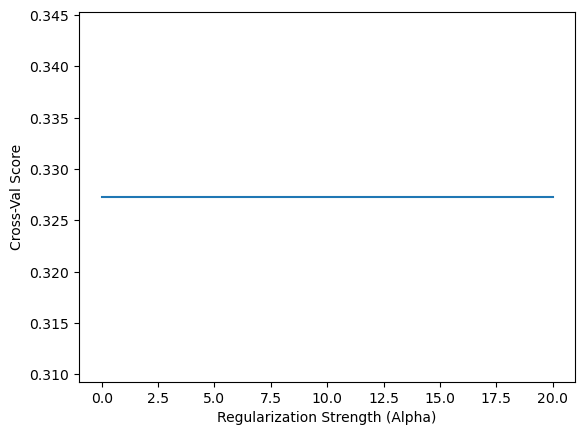

In [32]:
alpha = [1e-15, 1e-10, 1e-8, 1e-4, 1e-3,1e-2, 1, 5, 10, 20]
cv_score = [] 
for val in alpha:
    lr = LinearRegression()
    cv_score.append(cross_val_score(ridge_model, x_train_s, y_train, cv = 5).mean())
plt.plot(alpha, cv_score)
plt.xlabel("Regularization Strength (Alpha)")
plt.ylabel("Cross-Val Score")
plt.show()

In [6]:
cross_val_score(lr, x_train_s, y_train, cv = 5).mean()

np.float64(0.3266312457200012)

In [7]:
cross_val_score(lr, x_train_s, y_train, cv = 5)

array([-0.49853067,  0.62497424,  0.64820216,  0.58416877,  0.27434174])

In [31]:
y_pred = lr.predict(x_test_s)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
r2_score = regressor.score(x_test_s, y_test)
print(f'mae: {mae}')
print(f'mse: {mse}')
print(f'rmse: {rmse}')
print(f'r2_score: {r2_score}')

mae: 0.1690106242234809
mse: 0.913218598765835
rmse: 0.913218598765835
r2_score: 0.4298218289915623


In [48]:
params = {
         "fit_intercept": [True, False],
         "copy_X":[True, False],
         "tol":[0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],
         "positive": [True, False]
         }
model=GridSearchCV(estimator = LinearRegression(), param_grid=params, cv=4)
model.fit(x_train_s,y_train)
no_of_combinations = 1
for key, value in params.items():
    no_of_combinations *= len(value)
print("best params: ", model.best_params_)
print("best score: ", model.best_score_)

best params:  {'copy_X': True, 'fit_intercept': True, 'positive': False, 'tol': 0.0001}
best score:  0.39424691595456773


In [ ]:
#This best score is somehow worse than previous scores. 

In [23]:
ridge_model.fit(x_train_s, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


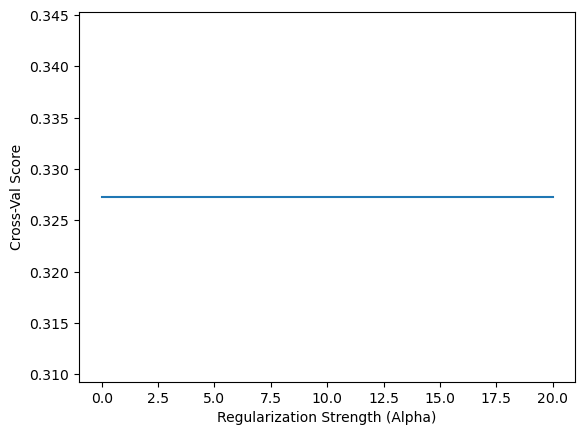

In [8]:
alpha = [1e-15, 1e-10, 1e-8, 1e-4, 1e-3,1e-2, 1, 5, 10, 20]
cv_score = [] 
for val in alpha:
    ridge_model = Ridge(alpha=0.1)
    cv_score.append(cross_val_score(ridge_model, x_train_s, y_train, cv = 5).mean())
plt.plot(alpha, cv_score)
plt.xlabel("Regularization Strength (Alpha)")
plt.ylabel("Cross-Val Score")
plt.show()

In [ ]:
#tested different regularization strengths as well as alphas and no change unless error. just a flat line.

In [50]:
y_pred2 = ridge_model.predict(x_test_s)
mae = mean_absolute_error(y_test, y_pred2)
mse = mean_squared_error(y_test, y_pred2)
rmse = mean_squared_error(y_test, y_pred2)
r2_score = ridge_model.score(x_test_s, y_test)
print(f'mae: {mae}')
print(f'mse: {mse}')
print(f'rmse: {rmse}')
print(f'r2_score: {r2_score}')

mae: 0.15864699981699484
mse: 0.9089447948187568
rmse: 0.9089447948187568
r2_score: 0.5904923187444042


In [ ]:
params = {
         "alpha" :[0.1],
         "fit_intercept": [True, False],
         "copy_X":[True, False],
         "max_iter":[1, 10, 100, 1000]
         "tol":[0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],
         "solver":['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'],
         "positive": [True, False]
         }
model=GridSearchCV(estimator = Ridge(random_state=518), param_grid=params, cv=4)
model.fit(x_train_s,y_train)
no_of_combinations = 1
for key, value in params.items():
    no_of_combinations *= len(value)
print("best params: ", model.best_params_)
print("best score: ", model.best_score_)

In [ ]:
#Tried running it and it took 7 hours and produced nothing.

In [34]:
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(x_train_s, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


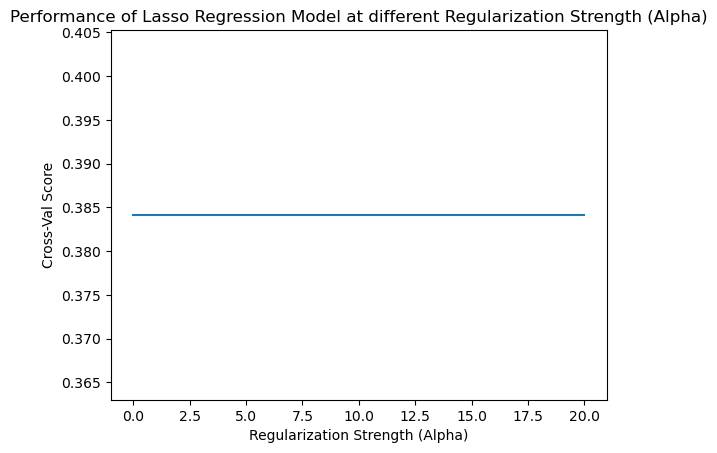

In [11]:
cv_score = []
for val in alpha:
    lasso_model = Lasso(alpha=0.1)
    cv_score.append(cross_val_score(lasso_model, x_train_s, y_train, cv = 5).mean())
plt.plot(alpha, cv_score)
plt.title("Performance of Lasso Regression Model at different Regularization Strength (Alpha)")
plt.xlabel("Regularization Strength (Alpha)")
plt.ylabel("Cross-Val Score")
plt.show()

In [36]:
y_pred3 = lasso_model.predict(x_test_s)
mae = mean_absolute_error(y_test, y_pred3)
mse = mean_squared_error(y_test, y_pred3)
rmse = mean_squared_error(y_test, y_pred3)
r2_score = lasso_model.score(x_test_s, y_test)
print(f'mae: {mae}')
print(f'mse: {mse}')
print(f'rmse: {rmse}')
print(f'r2_score: {r2_score}')

mae: 0.0983419753736168
mse: 0.9028176377367325
rmse: 0.9028176377367325
r2_score: 0.5932527921016985


In [57]:
params = {
         "alpha" :[0.1],
         "fit_intercept": [True, False],
         "precompute": [True, False],
         "copy_X":[True, False],
         "max_iter":[1, 10, 100, 1000],
         "tol":[0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],
         "warm_start": [True, False],
         "positive": [True, False],
         "selection": ['cyclical', 'random']
         }
model=GridSearchCV(estimator = Lasso(random_state=518), param_grid=params, cv=4)
model.fit(x_train_s,y_train)
no_of_combinations = 1
for key, value in params.items():
    no_of_combinations *= len(value)
print("best params: ", model.best_params_)
print("best score: ", model.best_score_)

best params:  {'alpha': 0.1, 'copy_X': True, 'fit_intercept': True, 'max_iter': 10, 'positive': True, 'precompute': True, 'selection': 'random', 'tol': 0.1, 'warm_start': True}
best score:  0.4509654670258256


In [ ]:
#The score again is worse than without tuning.. 

In [10]:
x2 = sm.add_constant(x_train_s)
lr = sm.OLS(y_train,x2).fit()
print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:             Fatalities   R-squared:                       0.590
Model:                            OLS   Adj. R-squared:                  0.578
Method:                 Least Squares   F-statistic:                     50.57
Date:                Fri, 13 Feb 2026   Prob (F-statistic):               0.00
Time:                        23:00:08   Log-Likelihood:                -74125.
No. Observations:               54349   AIC:                         1.513e+05
Df Residuals:                   52845   BIC:                         1.646e+05
Df Model:                        1503                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

In [39]:
knn= KNeighborsRegressor(n_neighbors=5)
knn.fit(x_train_s, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [40]:
y_pred4=knn.predict(x_test_s)
mae = mean_absolute_error(y_test, y_pred4)
mse = mean_squared_error(y_test, y_pred4)
rmse = mean_squared_error(y_test, y_pred4)
r2_score = knn.score(x_test_s, y_test)
print(f'mae: {mae}')
print(f'mse: {mse}')
print(f'rmse: {rmse}')
print(f'r2_score: {r2_score}')

mae: 0.09705622608183692
mse: 1.2655696202531646
rmse: 1.2655696202531646
r2_score: 0.4298218289915623


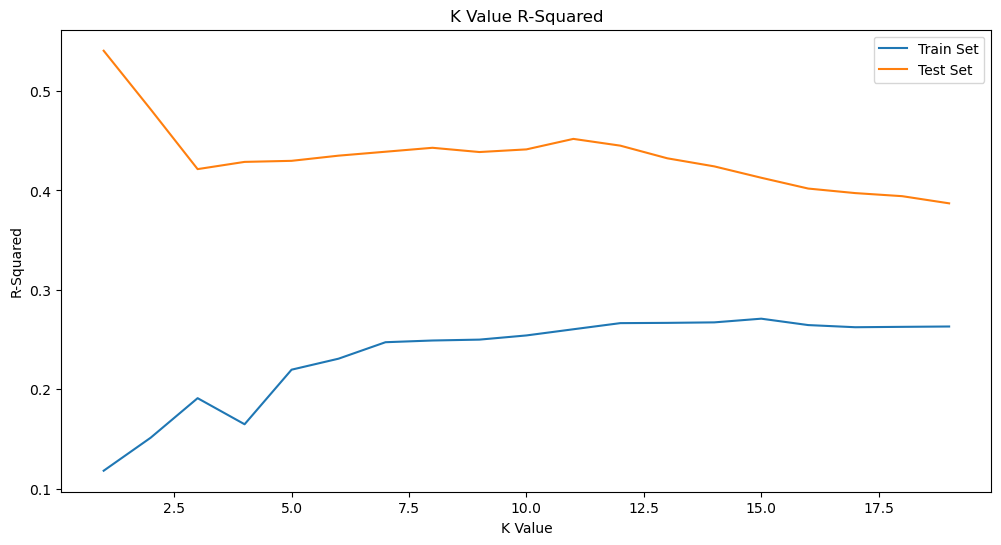

In [14]:
train_score = []
test_score = []
for i in range(1, 20):
    knn = KNeighborsRegressor(n_neighbors=i)
    train_score.append(cross_val_score(knn,x_train_s,y_train,cv=5).mean())
    knn.fit(x_train_s,y_train)
    test_score.append(knn.score(x_test_s, y_test))
plt.figure(figsize=(12, 6))
plt.plot(range(1, 20), train_score, markersize=10, label = "Train Set")
plt.plot(range(1, 20), test_score, markersize=10, label = "Test Set")
plt.title('K Value R-Squared')
plt.xlabel('K Value')
plt.ylabel('R-Squared')
plt.legend()

In [1]:
#The k-value for R-Squared peaks at about 5 in the test set, meaning that your k value in knn should be around 5 in the test set for best explain

In [43]:
knn2= KNeighborsRegressor(n_neighbors=3)
knn2.fit(x_train_s, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [44]:
y_pred5=knn2.predict(x_test_s)
mae = mean_absolute_error(y_test, y_pred5)
mse = mean_squared_error(y_test, y_pred5)
rmse = mean_squared_error(y_test, y_pred5)
r2_score = knn2.score(x_test_s, y_test)
print(f'mae: {mae}')
print(f'mse: {mse}')
print(f'rmse: {rmse}')
print(f'r2_score: {r2_score}')

mae: 0.09729172799528996
mse: 1.2840741831027378
rmse: 1.2840741831027378
r2_score: 0.42148495235353933


In [ ]:
params = {
         "n_neighbors" :[1,2,3,5,10,15,20],
         "weights": ['uniform', 'distance'],
         "algorithm":['auto', 'ball_tree', 'kd_tree','brute'],
         "leaf_size":[1, 5, 10, 15, 20, 30 100],
         }
model=GridSearchCV(estimator = knn(), param_grid=params, cv=4)
model.fit(x_train_s,y_train)
no_of_combinations = 1
for key, value in params.items():
    no_of_combinations *= len(value)
print("best params: ", model.best_params_)
print("best score: ", model.best_score_)

In [60]:
tree = DecisionTreeRegressor(random_state=518, max_depth=4, max_leaf_nodes=4)

In [61]:
tree.fit(x_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",518
,"max_lea

In [62]:
y_pred6=tree.predict(x_test)
mae = mean_absolute_error(y_test, y_pred6)
mse = mean_squared_error(y_test, y_pred6)
rmse = mean_squared_error(y_test, y_pred6)
r2_score = knn2.score(x_test, y_test)
print(f'mae: {mae}')
print(f'mse: {mse}')
print(f'rmse: {rmse}')
print(f'r2_score: {r2_score}')

mae: 0.12041541965216346
mse: 0.821572199611922
rmse: 0.821572199611922
r2_score: -3.979539021193773


<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

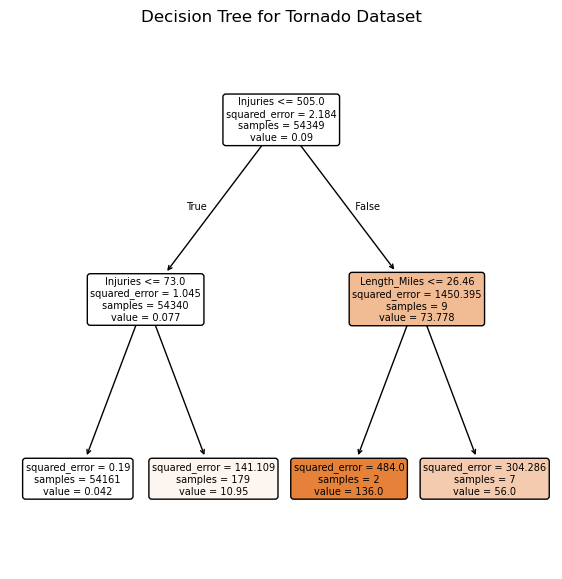

In [66]:
plt.figure(figsize=(7, 7))
plot_tree(tree, filled=True, rounded=True, feature_names=x_train.columns)
plt.title("Decision Tree for Tornado Dataset")
plt.show()

In [83]:
params = {
         "max_depth" :[1,2,3,5],
         "min_samples_split": [1,2,3],
         "min_samples_leaf":[1,2,3,4,5],
         "max_features":[1, 5, 10, 15, 20, 30, 100],
         "max_leaf_nodes": [1,2,3,4]
         }
model=GridSearchCV(estimator = tree, param_grid=params, cv=4)
model.fit(x_train,y_train)
no_of_combinations = 1
for key, value in params.items():
    no_of_combinations *= len(value)
print("best params: ", model.best_params_)
print("best score: ", model.best_score_)

best params:  {'max_depth': 3, 'max_features': 20, 'max_leaf_nodes': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
best score:  0.00010575939724810635


In [67]:
ada=AdaBoostRegressor()

In [68]:
ada.fit(x_train_s,y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.If ``None``, then the base estimator is:class:`~sklearn.tree.DecisionTreeRegressor` initialized with`max_depth=3`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each regressor at each boosting iteration. A higherlearning rate increases the contribution of each regressor. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"loss loss: {'linear', 'square', 'exponential'}, default='linear'The loss function to use when updating the weights after eachboosting iteration.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.In addition, it controls the bootstrap of the weights used to train the`estimator` at each boosting iteration.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [69]:
y_pred7=ada.predict(x_test_s)
mae = mean_absolute_error(y_test, y_pred7)
mse = mean_squared_error(y_test, y_pred7)
rmse = mean_squared_error(y_test, y_pred7)
r2_score = ada.score(x_test_s, y_test)
print(f'mae: {mae}')
print(f'mse: {mse}')
print(f'rmse: {rmse}')
print(f'r2_score: {r2_score}')

mae: 4.718558046480414
mse: 22.512650336597762
rmse: 22.512650336597762
r2_score: -9.142643745593421


In [ ]:
params = {
         "n_estimators": [1, 5, 10, 20, 50, 100],
         "learning_rate":[0.001, 0.01, 0.1, 1, 10],
         "loss":['linear', 'square', 'exponential']
         }
model=GridSearchCV(AdaBoostRegressor(), param_grid=params, cv=4)
model.fit(x_train_s,y_train)
no_of_combinations = 1
for key, value in params.items():
    no_of_combinations *= len(value)
print("best params: ", model.best_params_)
print("best score: ", model.best_score_)

In [ ]:
#again took too long to run

In [80]:
xg = XGBRegressor(random_state=518)

In [78]:
xg.fit(x2_train,y2_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [79]:
y_pred8=xg.predict(x2_test)
mae = mean_absolute_error(y2_test, y_pred8)
mse = mean_squared_error(y2_test, y_pred8)
rmse = mean_squared_error(y2_test, y_pred8)
r2_score = xg.score(x2_test, y2_test)
print(f'mae: {mae}')
print(f'mse: {mse}')
print(f'rmse: {rmse}')
print(f'r2_score: {r2_score}')

mae: 0.006953197531402111
mse: 0.18596884608268738
rmse: 0.18596884608268738
r2_score: 0.9572452306747437


In [ ]:
params = {
         "n_estimators": [1, 5, 10, 20, 50, 100],
         "learning_rate":[0.001, 0.01, 0.1, 1, 10],
         "max_depth": [1,3,5,7,10,15,30]
         }
model=GridSearchCV(XGBRegressor(), param_grid=params, cv=4)
model.fit(x2_train,y2_train)
no_of_combinations = 1
for key, value in params.items():
    no_of_combinations *= len(value)
print("best params: ", model.best_params_)
print("best score: ", model.best_score_)

In [ ]:
#Took too long to run as well, even tho I didn't use that many parameters for it